# Fantasy vs Reality
This project examines whether fantasy football quarterback scoring aligns with real NFL team success.

## Introduction
Fantasy football is a massive industry played by millions each year. It converts individual player statistics into a single scoring metric intended to represent performance during NFL games. For quarterbacks, scoring systems reward both passing and rushing production, with different weights assigned to each.

Real NFL football, however, is not designed to reward individual statistical output. Team success is determined solely by winning games, regardless of how those wins are achieved. While scoring points is the ultimate objective in both fantasy football and the NFL, fantasy scoring emphasizes individual box-score production, whereas real football prioritizes team-level outcomes. This distinction raises an important question about whether the types of quarterback production rewarded in fantasy football meaningfully align with what actually contributes to winning NFL games. 

The purpose of this project is to evaluate how closely quarterback fantasy football scoring aligns with real NFL team success, using team-season data from 2016 to 2025 and analyzing the relationship between fantasy production and win percentage. Alternative scoring systems will be tested to identify a fantasy scoring format that most closely aligns with how NFL teams win games.

## Data Sources
All data used in this project was sourced from [Pro Football Reference](https://www.pro-football-reference.com), a publicly available database of NFL statistics. Season-level passing and rushing statistics were collected for all players, along with final team standings. The analysis covers a ten-season span from 2016 through 2025, capturing the modern quarterback era.
Three datasets were collected:
- End-of-season passing statistics
- End-of-season rushing statistics
- Final team standings and records

## Data Preparation
Raw data from Pro Football Reference was downloaded annually and combined into three Excel spreadsheets: Passing, Rushing, and Team Records. Team names were cleaned and standardized into team abbreviations, and a season year field was added to each dataset.

The cleaned datasets were then loaded into a local SQLite database. SQL was used as the primary data-cleaning and aggregation layer to mirror a traditional data analyst workflow.

Passing and rushing statistics were filtered to include only quarterbacks and aggregated at the team-season level. The resulting tables were joined with team standings data to form a single dataset. Only statistics relevant to fantasy football scoring were retained, along with team win percentage.

The final dataset was structured at the team-season level, where each row represents a single NFL team in a given season. For each team-season, aggregated quarterback passing and rushing statistics (including yards, touchdowns, and turnovers) were paired with team win percentage to enable correlation and regression analysis.

In [1]:
import sqlite3
import pandas as pd

# create / connect to SQLite database
conn = sqlite3.connect("Fantasy vs Reality.db")

# load CSVs into pandas
passing = pd.read_csv("NFL Passing Data.csv")
rushing = pd.read_csv("NFL Rushing Stats 2016-2025.csv")
team_records = pd.read_csv("NFL Team Standings 2016-2025.csv")

# write to SQLite (replace on rerun)
passing.to_sql("passing", conn, if_exists="replace", index=False)
rushing.to_sql("rushing", conn, if_exists="replace", index=False)
team_records.to_sql("team_records", conn, if_exists="replace", index=False)

print("Database created and tables loaded.")

Database created and tables loaded.


In [2]:
sql = """
WITH p AS (
    SELECT Year, Team,
           SUM(Yds) AS PASS_YDS,
           SUM(TD)  AS PASS_TDS,
           SUM(Int) AS INTS
    FROM passing
    WHERE Pos = 'QB'
    GROUP BY Year, Team
),
r AS (
    SELECT Year, Team,
           SUM(Yds) AS RUSH_YDS,
           SUM(TD)  AS RUSH_TDS,
           SUM(Fmb) AS FUMBLES
    FROM rushing
    WHERE Pos = 'QB'
    GROUP BY Year, Team
)
SELECT
    p.Year,
    p.Team,
    p.PASS_YDS,
    p.PASS_TDS,
    p.INTS,
    COALESCE(r.RUSH_YDS, 0) AS RUSH_YDS,
    COALESCE(r.RUSH_TDS, 0) AS RUSH_TDS,
    COALESCE(r.FUMBLES, 0) AS FUMBLES,
    (w.W + 0.5*w.T) * 1.0 / (w.W + w.L + w.T) AS WIN_PCT
FROM p
LEFT JOIN r
  ON p.Team = r.Team AND p.Year = r.Year
JOIN team_records w
  ON p.Team = w.Tm AND p.Year = w.Year;
"""
df = pd.read_sql_query(sql, conn)

In [3]:
# Validation checks
df.shape
df.duplicated(['Year','Team']).sum()
df['WIN_PCT'].describe()

count    320.000000
mean       0.500103
std        0.191283
min        0.000000
25%        0.352941
50%        0.500000
75%        0.647059
max        0.882353
Name: WIN_PCT, dtype: float64

## Methods
After the datasets were joined using SQL, quarterback fantasy point totals were calculated at the team-season level under multiple fantasy scoring systems, and added as derived columns in the final dataset.
 
Three fantasy scoring formats were evaluated in this analysis. Each format assigns point values to passing and rushing production, with variations designed to test how weighting assumptions affect the relationship between fantasy performance and team success.

**Table 1.** Fantasy quarterback scoring formats evaluated in this analysis

| Scoring Component   | Standard        | Rushing Nerfed   | Passing Buffed   |
|--------------------|-----------------|------------------|------------------|
| Passing Yards      | 1 pt / 25 yds   | 1 pt / 25 yds    | 1 pt / 20 yds    |
| Passing TDs        | 4 pts           | 4 pts            | 6 pts            |
| Rushing Yards      | 1 pt / 10 yds   | 1 pt / 20 yds    | 1 pt / 10 yds    |
| Rushing TDs        | 6 pts           | 4 pts            | 6 pts            |
| Interceptions      | -2 pts          | -2 pts           | -2 pts           |
| Fumbles            | -2 pts          | -2 pts           | -2 pts           |

The Standard format represents typical quarterback fantasy scoring, awarding one point per 25 passing yards, four points per passing touchdown, one point per 10 rushing yards, six points per rushing touchdown, and negative two points for interceptions and fumbles.

The second format, Rushing Nerfed, reduces the relative value of quarterback rushing production to test how diminished rushing incentives affect the relationship between fantasy production and team success. 

The third format, Passing Buffed, increases the value of passing statistics to place greater emphasis on passing statistics.

Each fantasy scoring format was evaluated using correlation analysis against team win percentage. Correlation analysis was used to measure the strength and direction of the relationship between fantasy quarterback production and team win percentage, enabling comparison across scoring systems.

In addition to correlation testing, a linear regression analysis was conducted to assess the relative contributions of quarterback passing and rushing statistics to team win percentage. Regression coefficients were used to evaluate the direction and magnitude of the relationship between each quarterback statistic and team win percentage.

To construct a regression-informed scoring system, all coefficients were linearly rescaled such that the passing touchdown coefficient equaled six fantasy points, preserving the relative magnitudes implied by the model. This regression-scaled scoring system was evaluated using correlation analysis against team win percentage.

Finally, insights from the regression results were used to design a final fantasy scoring system with point values calibrated to maintain practical fantasy scoring while emphasizing the quarterback performance factors most strongly associated with winning NFL games.

## Correlation Analysis

In [4]:
# --- Standard Scoring ---
df['FANTASY_STANDARD'] = (
    df['PASS_YDS'] / 25 +
    df['PASS_TDS'] * 4 +
    df['RUSH_YDS'] / 10 +
    df['RUSH_TDS'] * 6 -
    df['INTS'] * 2 -
    df['FUMBLES'] * 2
)

# --- Rushing Nerfed ---
df['FANTASY_RUSH_NERFED'] = (
    df['PASS_YDS'] / 25 +
    df['PASS_TDS'] * 4 +
    df['RUSH_YDS'] / 20 +
    df['RUSH_TDS'] * 4 -
    df['INTS'] * 2 -
    df['FUMBLES'] * 2
)

# --- Passing Buffed ---
df['FANTASY_PASS_BUFFED'] = (
    df['PASS_YDS'] / 20 +
    df['PASS_TDS'] * 6 +
    df['RUSH_YDS'] / 10 +
    df['RUSH_TDS'] * 6 -
    df['INTS'] * 2 -
    df['FUMBLES'] * 2
)

In [21]:
from scipy.stats import pearsonr
import pandas as pd

cols = ['FANTASY_STANDARD', 'FANTASY_RUSH_NERFED', 'FANTASY_PASS_BUFFED']

pearson_results = {}

for col in cols:
    sub = df[[col, 'WIN_PCT']].dropna()

    r, p = pearsonr(sub[col], sub['WIN_PCT'])

    pearson_results[col] = {
        'r': r,
        'p': p
    }

# convert to clean table
df_results = pd.DataFrame(pearson_results).T

df_results

,r,p
FANTASY_STANDARD,0.568640,8.328119e-29
FANTASY_RUSH_NERFED,0.610384,4.737263e-34
FANTASY_PASS_BUFFED,0.585867,7.040925e-31


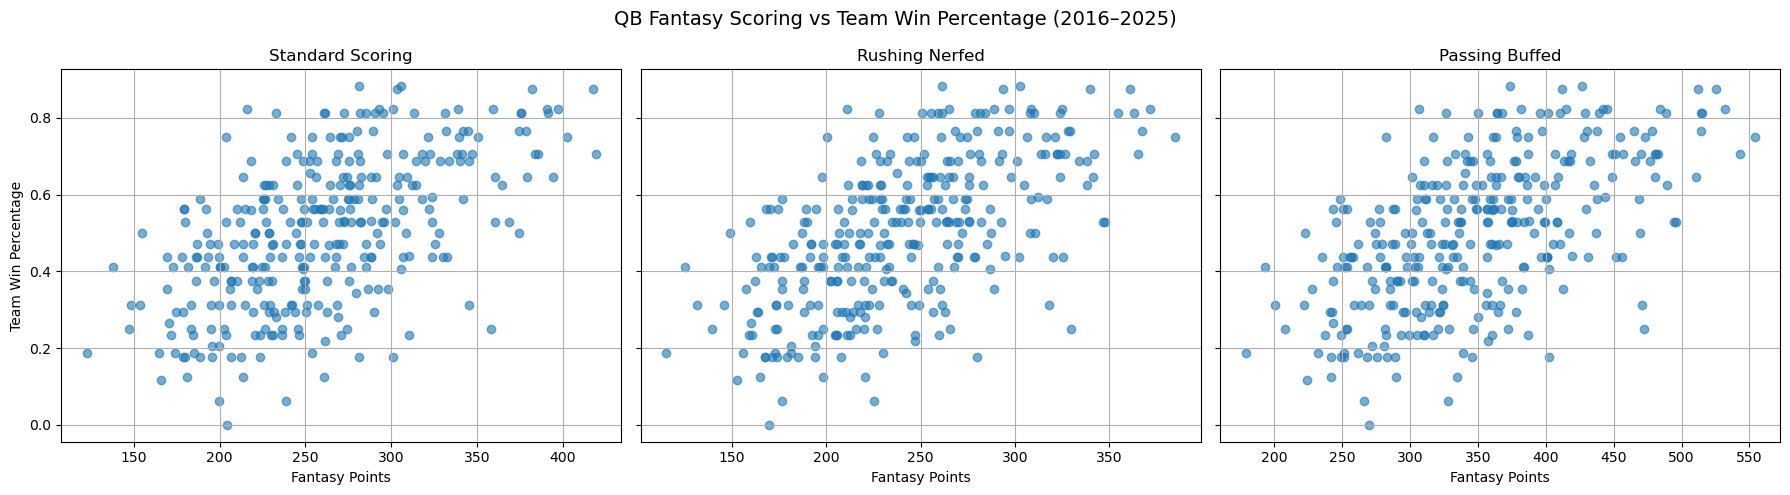

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

scoring_systems = [
    ('FANTASY_STANDARD', 'Standard Scoring'),
    ('FANTASY_RUSH_NERFED', 'Rushing Nerfed'),
    ('FANTASY_PASS_BUFFED', 'Passing Buffed'),
]

for ax, (col, title) in zip(axes, scoring_systems):
    ax.scatter(df[col], df["WIN_PCT"], alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Fantasy Points")
    ax.grid(True)

axes[0].set_ylabel("Team Win Percentage")

plt.suptitle("QB Fantasy Scoring vs Team Win Percentage (2016–2025)", fontsize=14)
plt.tight_layout()

**Figure 1.** Relationship between quarterback fantasy scoring and team win percentage across three scoring systems (2016–2025)

## Correlation Results
Across all scoring formats, quarterback fantasy production has a statistically significant positive correlation with team win percentage (p < 0.001). Under the Standard scoring format, fantasy quarterback points show a moderate positive relationship with team success (r = 0.57).

The Rushing Nerfed scoring format produces the highest observed correlation with team win percentage (r = 0.61), suggesting that reducing the value of quarterback rushing may slightly improve alignment with real NFL outcomes. The Passing Buffed format also shows a modest increase in correlation compared to the Standard format (r = 0.59), though to a lesser extent than the Rushing Nerfed format.

Overall, these results suggest that quarterback rushing production may be somewhat overemphasized in traditional fantasy scoring relative to its relationship with team success, although differences in correlation strength across scoring systems are relatively small.

## Regression Analysis

In [7]:
import statsmodels.api as sm

# Dependent and independent variables
X = df[['PASS_YDS', 'PASS_TDS', 'RUSH_YDS', 'RUSH_TDS', 'INTS', 'FUMBLES']]
y = df['WIN_PCT']

# Add x intercept
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Show results
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                WIN_PCT   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     43.34
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           2.07e-38
Time:                        16:03:54   Log-Likelihood:                 172.48
No. Observations:                 320   AIC:                            -331.0
Df Residuals:                     313   BIC:                            -304.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3717      0.078      4.789      0.000       0.219       0.524
PASS_YDS    9.441e-06    2.3e-05      0.410      0.682   -3.59e-05    5.47e-05
PASS_TDS       0.0118      0.002      7.166      0.000       0.009       0.015
RUSH_YDS    -4.14e-05   5.12e-05     -0.809      0.419      -0.000    5.93e-05
RUSH_TDS       0.0122      0.004      3.278      0.001       0.005       0.020
INTS          -0.0128      0.002     -6.681      0.000      -0.017      -0.009
FUMBLES       -0.0068      0.002     -2.912      0.004      -0.011      -0.002
==============================================================================
Omnibus:                        2.497   Durbin-Watson:                   2.112
Prob(Omnibus):                  0.287   Jarque-Bera (JB):                2.535
Skew:                          -0.212   Prob(JB):                        0.282
Kurtosis:                       2.898   Cond. No.                     3.92e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.92e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
model.params, model.pvalues, model.rsquared

(const       0.371722
 PASS_YDS    0.000009
 PASS_TDS    0.011752
 RUSH_YDS   -0.000041
 RUSH_TDS    0.012250
 INTS       -0.012806
 FUMBLES    -0.006824
 dtype: float64,
 const       2.590032e-06
 PASS_YDS    6.819989e-01
 PASS_TDS    5.587902e-12
 RUSH_YDS    4.189934e-01
 RUSH_TDS    1.163727e-03
 INTS        1.084836e-10
 FUMBLES     3.849224e-03
 dtype: float64,
 np.float64(0.45377750033976183))

## Regression Results

A linear regression was conducted to assess the relationship between quarterback fantasy production components and team win percentage. The model explains approximately 45% of the variation in team win percentage (R² = 0.45).

Passing touchdowns, rushing touchdowns, interceptions, and fumbles are all statistically significant predictors of team success (p < 0.01). However, passing yardage and rushing yardage are not statistically significant. These results suggest that quarterback scoring efficiency and ball security are more strongly associated with winning than raw yardage volume.

## Regression-Informed Fantasy System

**Table 2.** Regression Coefficients (WIN_PCT scale)

| Variable   | Coefficient |
|------------|-------------|
| PASS_YDS   | 0.000009    |
| PASS_TDS   | 0.011752    |
| RUSH_YDS   | −0.000041   |
| RUSH_TDS   | 0.012250    |
| INTS       | −0.012806   |
| FUMBLES    | −0.006824   |

**Scaling Passing Touchdowns to 6 Fantasy Points**

$$
\text{Scaling Factor} = \frac{6.0}{0.011752} \approx 510.6
$$

**Table 3.** Scaled Fantasy Point Values

| Stat       | Fantasy Points |
|------------|----------------|
| PASS_TD    | +6.00          |
| RUSH_TD    | +6.26          |
| INT        | −6.54          |
| FUMBLE     | −3.49          |
| PASS_YDS  | +0.0046 / yard |
| RUSH_YDS  | −0.0209 / yard |

These values represent a purely regression-informed system that preserves the relative importance and direction of each variable implied by the win percentage model. This system will be used as a guide to design the final scoring system, rather than a practical standalone fantasy format.

In [9]:
# Creating a Column for the Regression Informed System
df["FANTASY_REG_INFORMED"] = (
    6.00  * df["PASS_TDS"]
    + 6.26 * df["RUSH_TDS"]
    - 6.54 * df["INTS"]
    - 3.49 * df["FUMBLES"]
    + 0.0046 * df["PASS_YDS"]
    - 0.0209 * df["RUSH_YDS"]
)

In [22]:
from scipy.stats import pearsonr

r_reg, p_reg = pearsonr(df["FANTASY_REG_INFORMED"], df["WIN_PCT"])

pearson_results["FANTASY_REG_INFORMED"] = {
    "r": r_reg,
    "p": p_reg
}

df_results = pd.DataFrame(pearson_results).T
df_results

,r,p
FANTASY_STANDARD,0.568640,8.328119e-29
FANTASY_RUSH_NERFED,0.610384,4.737263e-34
FANTASY_PASS_BUFFED,0.585867,7.040925e-31
FANTASY_REG_INFORMED,0.673629,1.154416e-43


## Regression-Informed Scoring System Correlation Results

The regression-informed scoring system exhibited a strong positive correlation with team win percentage (Pearson r = 0.67, p < 0.001), outperforming all previously tested fantasy scoring formats.

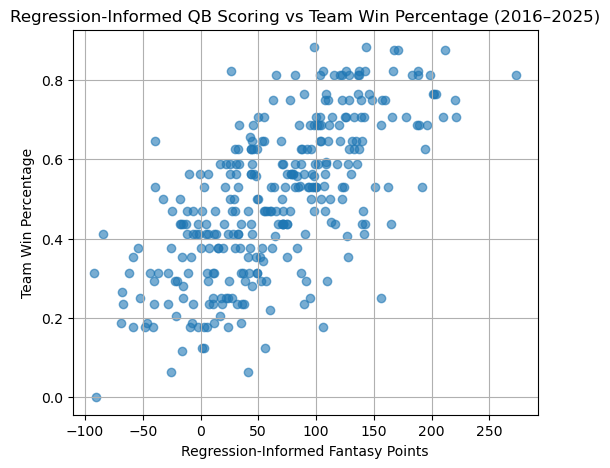

In [18]:
plt.figure(figsize=(6,5))
plt.scatter(df["FANTASY_REG_INFORMED"], df["WIN_PCT"], alpha=0.6)
plt.xlabel("Regression-Informed Fantasy Points")
plt.ylabel("Team Win Percentage")
plt.title("Regression-Informed QB Scoring vs Team Win Percentage (2016–2025)")
plt.grid(True)
plt.show()

**Figure 2.** Scatter plot of the relationship between regression-informed quarterback fantasy points and team win percentage for team-seasons from 2016–2025.

## Final Proposed Quarterback Fantasy Scoring System
The regression analysis revealed that touchdowns and turnovers are the quarterback performance variables most strongly aligned with NFL team success. While the regression-informed scoring system substantially improved alignment with win percentage, it is not practical in a fantasy football context. The resulting fantasy totals would be unrealistically low and significantly devalue the quarterback position, undermining the core appeal of fantasy football: scoring points.

The final proposed fantasy scoring format therefore seeks a middle ground. The goal is to preserve realistic quarterback fantasy output while adjusting scoring weights to better reflect how NFL teams actually win games. Yardage scoring, both passing and rushing, is reinstated at standard levels (1 point per 25 passing yards and 1 point per 10 rushing yards), as yardage remains the primary driver of fantasy scoring despite its limited independent contribution to winning in the regression results.

Passing touchdowns are increased to six points, a change supported by both the regression findings and the stronger correlation observed under the passing-buffed scoring format. Interceptions are increased to a −4 point penalty. This reflects the regression result that interceptions negatively impact winning to a greater degree than touchdowns positively contribute, while avoiding an overly punitive effect on total fantasy output. Fumbles remain at −2 points, consistent with standard fantasy scoring across all positions.

**Table 4.** Final Proposed Fantasy Scoring Format

| Statistic        | Fantasy Points |
|------------------|----------------|
| Passing Yards    | 1 point per 25 yards |
| Passing Touchdowns | 6 points |
| Rushing Yards    | 1 point per 10 yards |
| Rushing Touchdowns | 6 points |
| Interceptions    | −4 points |
| Fumbles          | −2 points |

In [12]:
# Creating a new column for the final proposed system
df["FP_FINAL"] = (
    df["PASS_YDS"] / 25
    + 6 * df["PASS_TDS"]
    + df["RUSH_YDS"] / 10
    + 6 * df["RUSH_TDS"]
    - 4 * df["INTS"]
    - 2 * df["FUMBLES"]
)

In [25]:
from scipy.stats import pearsonr

col = "FP_FINAL"

r_final, p_final = pearsonr(df[col], df["WIN_PCT"])

pearson_results[col] = {
    "r": r_final,
    "p": p_final
}

df_results = pd.DataFrame(pearson_results).T
df_results

,r,p
FANTASY_STANDARD,0.568640,8.328119e-29
FANTASY_RUSH_NERFED,0.610384,4.737263e-34
FANTASY_PASS_BUFFED,0.585867,7.040925e-31
FANTASY_REG_INFORMED,0.673629,1.154416e-43
FP_FINAL,0.613295,1.907263e-34


## Final Proposed Scoring System Correlation Results

The final proposed scoring system also demonstrated a strong positive correlation with team win percentage (Pearson r = 0.61, p < 0.001) while maintaining a more traditional fantasy scoring structure than the regression-informed model.

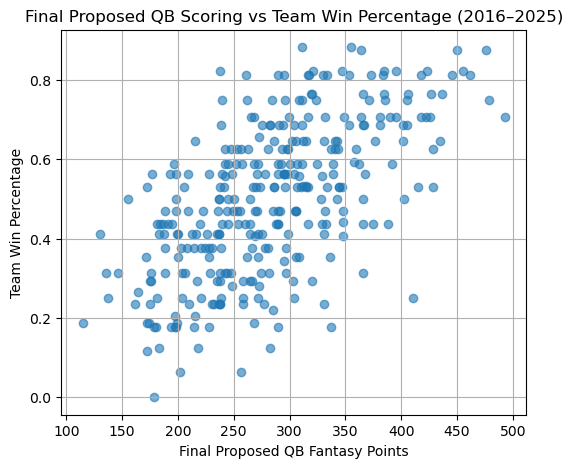

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(df["FP_FINAL"], df["WIN_PCT"], alpha=0.6)
plt.xlabel("Final Proposed QB Fantasy Points")
plt.ylabel("Team Win Percentage")
plt.title("Final Proposed QB Scoring vs Team Win Percentage (2016–2025)")
plt.grid(True)
plt.show()

**Figure 3.** Relationship between the final proposed quarterback fantasy scoring system and team win percentage across NFL team-seasons from 2016–2025.

## Summary of Results


Table 5 summarizes the relationships between each evaluated quarterback fantasy scoring system and NFL team success. Overall, the results demonstrate that all scoring systems produce strong and statistically significant correlations with winning, with modified scoring systems generally showing slightly stronger relationships than traditional fantasy scoring formats. Figure 4 visualizes these relationships across each scoring system, reinforcing the consistency of the observed correlations.

**Table 5.** Pearson Correlation Between QB Fantasy Scoring Systems and Team Win Percentage (2016–2025)

| Scoring System        | Pearson r | p-value          |
|----------------------|-----------|------------------|
| Regression-Informed  | 0.674     | 1.15 × 10⁻⁴³     |
| Final Proposed       | 0.613     | 1.91 × 10⁻³⁴     |
| Rushing Nerfed       | 0.610     | 4.74 × 10⁻³⁴     |
| Passing Buffed       | 0.586     | 7.04 × 10⁻³¹     |
| Standard             | 0.569     | 8.33 × 10⁻³⁴     |

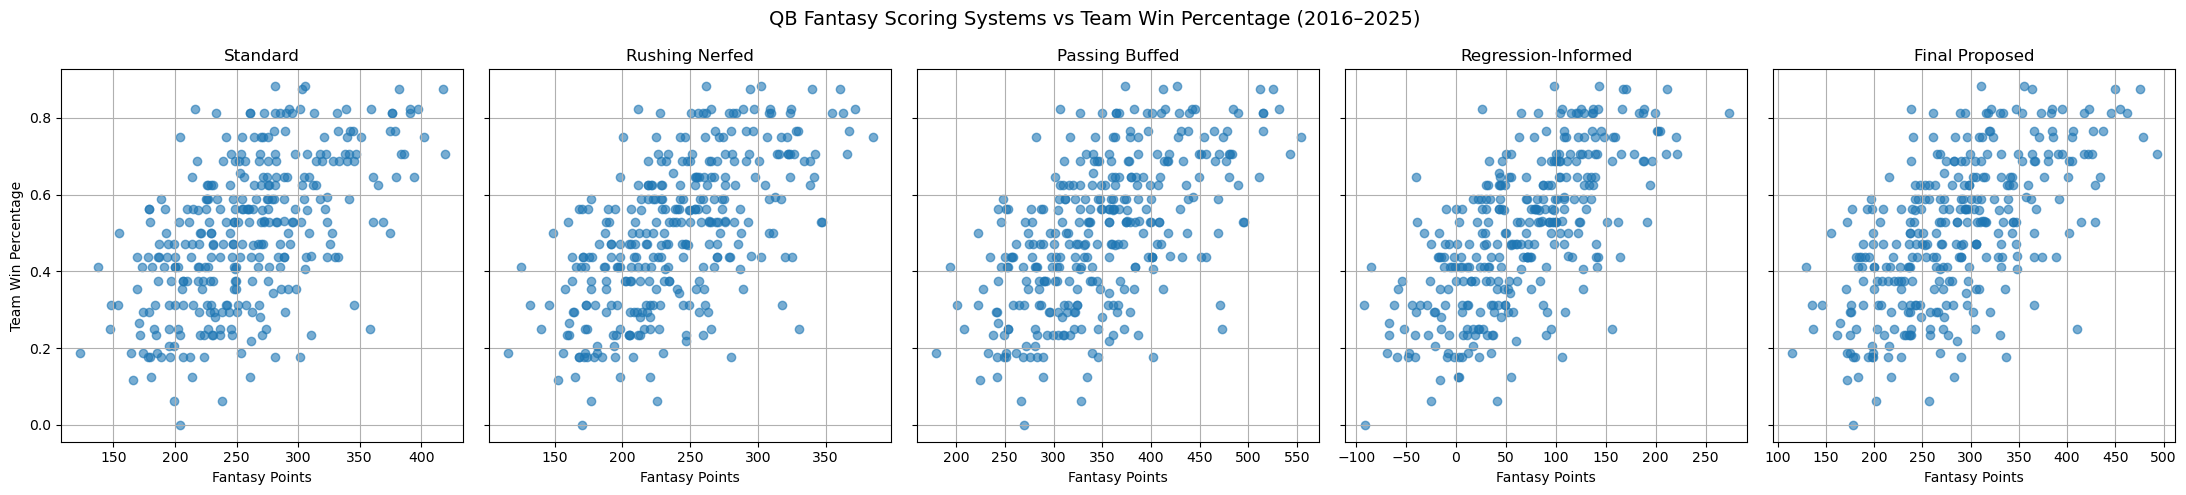

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

systems_plot = [
    ("FANTASY_STANDARD", "Standard"),
    ("FANTASY_RUSH_NERFED", "Rushing Nerfed"),
    ("FANTASY_PASS_BUFFED", "Passing Buffed"),
    ("FANTASY_REG_INFORMED", "Regression-Informed"),
    ("FP_FINAL", "Final Proposed"),
]

for ax, (col, title) in zip(axes, systems_plot):
    ax.scatter(df[col], df["WIN_PCT"], alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Fantasy Points")
    ax.grid(True)

axes[0].set_ylabel("Team Win Percentage")

plt.suptitle(
    "QB Fantasy Scoring Systems vs Team Win Percentage (2016–2025)",
    fontsize=14
)

plt.tight_layout()
plt.show()


**Figure 4.** Comparison of relationships between quarterback fantasy scoring systems and team win percentage.

## Discussion

The core question this study sought to answer was whether quarterback fantasy scoring was correlated with NFL team success and, if so, to what extent. The results showed a strong association between quarterback fantasy scoring and team success across all evaluated scoring systems. This indicates that fantasy football is meaningfully associated with winning football, though the analysis cannot fully determine whether fantasy production directly contributes to winning or is simply correlated with successful team environments.

The study then expanded into examining how current fantasy scoring systems could be adjusted to better align with NFL team success. Standard fantasy scoring already demonstrated a strong relationship with winning, while the passing-buffed and rushing-nerfed formats showed slightly higher correlations with team success. The rushing-nerfed format produced the strongest correlation with team success among the traditional scoring modifications. Reducing the value of quarterback rushing production placed greater emphasis on passing statistics and turnovers, suggesting that these factors are more closely associated with winning in the NFL.

These findings were further supported by the regression analysis, which identified touchdowns and turnovers as the variables most strongly associated with team success. Passing touchdowns, rushing touchdowns, and interceptions all demonstrated similarly strong relationships with winning, while fumbles showed a weaker association. In contrast, both passing yards and rushing yards appeared relatively insignificant in relation to touchdowns and turnovers. The analysis also showed interceptions to be approximately twice as impactful as fumbles in relation to team success. One possible explanation is that interceptions create greater opportunities for defensive returns and sudden changes in field position. However, this relationship would require additional study to fully evaluate.

A regression-informed fantasy scoring system was then created using the scaled regression coefficients and produced the strongest overall correlation with team success. However, the resulting scoring structure was significantly less practical and enjoyable for actual fantasy football gameplay. Fantasy football is designed to create engaging, high-scoring competition based on player statistics, and heavily reducing the value of yardage statistics would substantially lower the excitement of the game. This represents the central tradeoff identified in the study: maximizing statistical alignment with NFL success versus maintaining balanced and entertaining fantasy gameplay.

As a result, a final proposed scoring system was developed to balance these competing goals by increasing the value of touchdowns and interceptions while preserving traditional yardage scoring structures. Overall, the findings suggest that fantasy football scoring systems can be meaningfully adjusted to better reflect real NFL success without completely abandoning traditional fantasy football principles.

## Limitations

The project produced several key findings, but there remains significant opportunity for future work and improvement. The study focuses on team win percentage and quarterback statistics at the team-season level, which reduces precision and contextual detail compared to a game-level analysis. Future research may examine individual game outcomes and how winning correlates with quarterback fantasy performance on a weekly basis. The scope of the study was also limited to data from the 2016–2025 NFL seasons. Future work could examine a larger historical range to provide a broader perspective on the relationship between fantasy production and team success across NFL history, and could also segment different NFL eras to compare how quarterback fantasy production correlates with winning across changing styles of football.

Fantasy football scoring primarily utilizes major quarterback statistics such as touchdowns, yards, and turnovers, but does not incorporate advanced efficiency metrics. This study examined current fantasy scoring formats, but future work could explore hypothetical scoring systems that utilize advanced metrics such as EPA and QBR. These metrics may hold potential in creating fantasy scoring systems that align more closely with team success.

While the analysis identified strong statistical relationships between quarterback fantasy production and team success, correlation alone cannot fully isolate the independent impact of quarterback performance from broader team and game context. Quarterback fantasy production may also be influenced by factors such as coaching, supporting cast, game script, and overall team quality.

Finally, this study focused specifically on quarterback fantasy scoring due to the position’s substantial impact on NFL team success. Future work could examine how fantasy production at other positions, such as running back, wide receiver, and tight end, relates to team winning percentage.

## Conclusion

The results indicate that quarterback fantasy scoring is significantly associated with real NFL team success across all evaluated scoring systems. This suggests that fantasy football scoring is meaningfully reflective of on-field performance rather than being entirely disconnected from real football outcomes.

Among the scoring systems tested, modified formats such as the passing-buffed and rushing-nerfed systems showed slightly stronger relationships with team success than standard fantasy scoring, with the rushing-nerfed format producing the highest correlation overall.

Regression analysis further supported that passing touchdowns and turnovers are the most important quarterback-related factors associated with winning, while yardage statistics contribute relatively little to team success compared to traditional fantasy scoring assumptions.

Although the regression-informed scoring system produced the strongest statistical alignment with team success, it was not practical for fantasy football gameplay due to reduced balance and usability. As a result, a final proposed scoring system was developed that increases the value of passing touchdowns and interceptions while preserving standard scoring for other categories.

Overall, the findings demonstrate that quarterback fantasy scoring does reflect real NFL team success, and that scoring systems can be adjusted to better align fantasy outcomes with real-world performance while maintaining playable fantasy structure.